In [1]:
import pandas as pd
import numpy as np

train = pd.read_csv(
    "../data/processed/failure_train.csv",
    parse_dates=["snapshot_date"]
)

validation = pd.read_csv(
    "../data/processed/failure_validation.csv",
    parse_dates=["snapshot_date"]
)

test = pd.read_csv(
    "../data/processed/failure_test.csv",
    parse_dates=["snapshot_date"]
)

print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)


Train: (72000, 14)
Validation: (12000, 14)
Test: (7000, 14)


In [2]:
feature_columns = [
    "asset_age_years",
    "condition_score",
    "criticality",
    "usage_factor",
    "weather_stress",
    "historical_failure_count",
    "historical_downtime_hours",
    "days_since_last_failure"
]

target_column = "failure_within_30_days"

In [3]:
X_train = train[feature_columns]
y_train = train[target_column]

X_validation = validation[feature_columns]
y_validation = validation[target_column]

X_test = test[feature_columns]
y_test = test[target_column]

In [4]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)

X_validation_imputed = imputer.transform(X_validation)

X_test_imputed = imputer.transform(X_test)

In [5]:
from sklearn.ensemble import RandomForestClassifier

In [6]:
random_forest = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [7]:
random_forest.fit(
    X_train_imputed,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fea

In [8]:
y_pred = random_forest.predict(
    X_test_imputed
)

In [9]:
y_probability = random_forest.predict_proba(
    X_test_imputed
)[:, 1]

In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [11]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test, y_probability))

Accuracy : 0.8834285714285715
Precision: 0.0051813471502590676
Recall   : 0.07692307692307693
F1 Score : 0.009708737864077669
ROC-AUC  : 0.5321619945972278


In [12]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[6180  768]
 [  48    4]]


In [13]:
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.89      0.94      6948
           1       0.01      0.08      0.01        52

    accuracy                           0.88      7000
   macro avg       0.50      0.48      0.47      7000
weighted avg       0.98      0.88      0.93      7000



In [14]:
train_pred = random_forest.predict(
    X_train_imputed
)

print(
    "Training F1:",
    f1_score(
        y_train,
        train_pred,
        zero_division=0
    )
)

print(
    "Test F1:",
    f1_score(
        y_test,
        y_pred,
        zero_division=0
    )
)

Training F1: 0.07182193666819642
Test F1: 0.009708737864077669


In [15]:
validation_pred = random_forest.predict(
    X_validation_imputed
)

validation_probability = random_forest.predict_proba(
    X_validation_imputed
)[:, 1]

In [16]:
print(
    "Validation F1:",
    f1_score(
        y_validation,
        validation_pred,
        zero_division=0
    )
)

print(
    "Validation ROC-AUC:",
    roc_auc_score(
        y_validation,
        validation_probability
    )
)

Validation F1: 0.015082956259426848
Validation ROC-AUC: 0.6166335757343795


In [17]:
importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": random_forest.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance

,feature,importance
1,condition_score,0.269974
4,weather_stress,0.196477
0,asset_age_years,0.156890
3,usage_factor,0.149795
7,days_since_last_failure,0.071728
6,historical_downtime_hours,0.068059
2,criticality,0.067780
5,historical_failure_count,0.019295


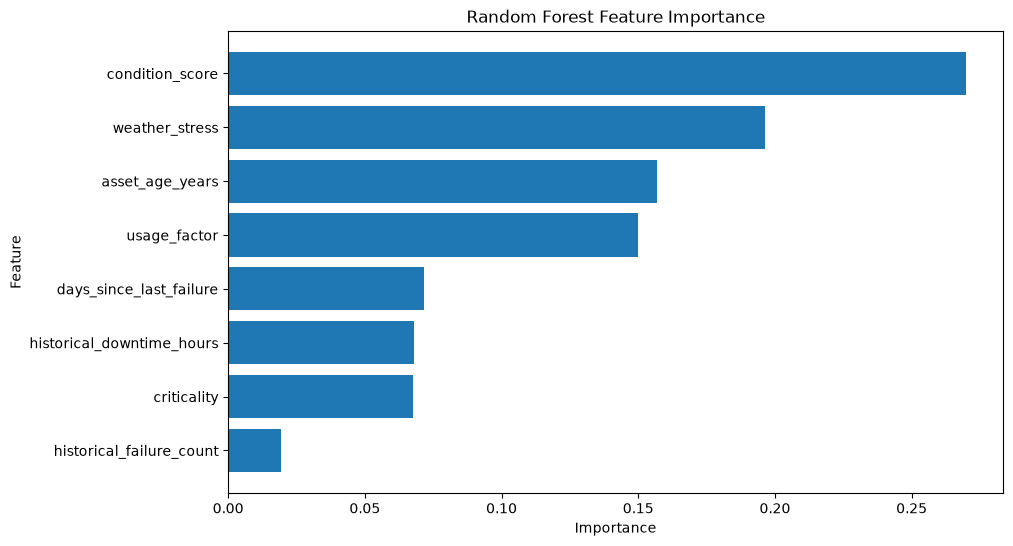

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    importance["feature"],
    importance["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [19]:
random_forest_results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1": f1_score(y_test, y_pred, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, y_probability)
}

random_forest_results

{'Accuracy': 0.8834285714285715,
 'Precision': 0.0051813471502590676,
 'Recall': 0.07692307692307693,
 'F1': 0.009708737864077669,
 'ROC_AUC': 0.5321619945972278}

In [20]:
rf_predictions = test[
    [
        "asset_id",
        "section_id",
        "department",
        "asset_type",
        "snapshot_date",
        "condition_score",
        "criticality",
        "historical_failure_count",
        "failure_within_30_days"
    ]
].copy()

rf_predictions["failure_probability"] = y_probability

rf_predictions["predicted_failure"] = y_pred

In [21]:
rf_predictions = rf_predictions.sort_values(
    "failure_probability",
    ascending=False
)

In [22]:
rf_predictions.head(20)

,asset_id,section_id,department,asset_type,snapshot_date,condition_score,criticality,historical_failure_count,failure_within_30_days,failure_probability,predicted_failure
2191,ASSET00314,NDL-MTJ-01,TRACTION,OHE,2026-01-01,75.975178,7,2,0,0.723399,1
1435,ASSET00206,NDL-MTJ-01,TRACTION,SECTIONING_POST,2026-01-01,67.384631,7,1,0,0.709683,1
2196,ASSET00314,NDL-MTJ-01,TRACTION,OHE,2026-06-01,72.888155,7,2,0,0.701312,1
4516,ASSET00646,VAD-SRT-01,TRACTION,TRANSFORMER,2026-02-01,68.240416,8,0,0,0.697243,1
3853,ASSET00551,VAD-SRT-01,S&T,POINT_MACHINE,2026-04-01,67.801360,6,1,0,0.696942,1
2194,ASSET00314,NDL-MTJ-01,TRACTION,OHE,2026-04-01,65.700761,7,2,0,0.692219,1
3854,ASSET00551,VAD-SRT-01,S&T,POINT_MACHINE,2026-05-01,68.262156,6,1,0,0.690868,1
151,ASSET00022,VAD-SRT-01,ENGINEERING,TURNOUT,2026-05-01,65.773836,8,0,0,0.690497,1
2192,ASSET00314,NDL-MTJ-01,TRACTION,OHE,2026-02-01,76.456287,7,2,0,0.690117,1
1292,ASSET00185,VAD-SRT-01,S&T,AXLE_COUNTER,2026-05-01,79.174733,7,2,0,0.688728,1


In [23]:
import os

os.makedirs(
    "../data/predictions",
    exist_ok=True
)

rf_predictions.to_csv(
    "../data/predictions/random_forest_failure_predictions.csv",
    index=False
)

In [24]:
rf_unbalanced = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=10,
    class_weight=None,
    random_state=42,
    n_jobs=-1
)

In [25]:
rf_unbalanced.fit(
    X_train_imputed,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total 

In [26]:
unbalanced_pred = rf_unbalanced.predict(
    X_test_imputed
)

unbalanced_probability = rf_unbalanced.predict_proba(
    X_test_imputed
)[:, 1]

In [27]:
print(
    "Unbalanced Recall:",
    recall_score(
        y_test,
        unbalanced_pred,
        zero_division=0
    )
)

print(
    "Unbalanced F1:",
    f1_score(
        y_test,
        unbalanced_pred,
        zero_division=0
    )
)

print(
    "Unbalanced ROC-AUC:",
    roc_auc_score(
        y_test,
        unbalanced_probability
    )
)

Unbalanced Recall: 0.0
Unbalanced F1: 0.0
Unbalanced ROC-AUC: 0.6201923076923076
